# Gen Z Content Consumption Analysis

This notebook analyzes social media and content consumption patterns among 
Gen Z users, exploring platform preferences, usage habits, and their 
relationship with lifestyle factors like sleep and mental well-being.

**Dataset:** 8,000 sampled records from a Gen Z social media usage dataset  
**Tools:** Python (Pandas, Matplotlib, Seaborn)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading & Cleaning

Loading the dataset and checking for missing values, duplicates, and 
inconsistent categories before starting analysis.

In [3]:
df=pd.read_csv('genz_content_consumption_sample.csv')

In [4]:
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,25,Female,Brazil,2.721398,YouTube,3,Entertainment,17.687304,1,6.498836,Medium,57.511201
1,22,Male,Canada,4.259008,YouTube,2,Socializing,30.053853,1,4.852140,Medium,30.380069
2,15,Male,India,1.597300,Instagram,1,Content Creation,14.295109,0,8.513620,Low,43.968642
3,14,Male,Australia,2.914241,TikTok,5,Socializing,25.444925,0,7.512457,Medium,47.783313
4,21,Female,India,2.898776,TikTok,5,News,14.967762,0,9.209529,Medium,59.543505


In [5]:
df.shape

(8000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       8000 non-null   int64  
 1   gender                    8000 non-null   object 
 2   country                   8000 non-null   object 
 3   daily_usage_hours         8000 non-null   float64
 4   primary_platform          8000 non-null   object 
 5   num_platforms_used        8000 non-null   int64  
 6   purpose                   8000 non-null   object 
 7   avg_session_minutes       8000 non-null   float64
 8   night_usage               8000 non-null   int64  
 9   mental_health_score       8000 non-null   float64
 10  addiction_level           8000 non-null   object 
 11  screen_time_before_sleep  8000 non-null   float64
dtypes: float64(4), int64(3), object(5)
memory usage: 750.1+ KB


In [7]:
df.isnull().sum()

age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.994000,3.526724,3.010375,25.044633,0.590125,7.162176,39.985174
std,4.294563,1.470901,1.420570,9.878666,0.491841,1.495858,19.423057
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.485126,2.000000,18.181559,0.000000,6.127934,26.527373
50%,20.000000,3.503419,3.000000,24.933981,1.000000,7.204395,39.762994
75%,24.000000,4.532936,4.000000,31.660588,1.000000,8.228708,53.261499
max,27.000000,9.465156,5.000000,61.195293,1.000000,10.000000,115.588362


In [10]:
df['primary_platform'].unique()

array(['YouTube', 'Instagram', 'TikTok', 'Snapchat', 'Twitter'],
      dtype=object)

In [11]:
df['country'].unique()

array(['Brazil', 'Canada', 'India', 'Australia', 'Germany', 'USA', 'UK'],
      dtype=object)

In [12]:
df['purpose'].unique()

array(['Entertainment', 'Socializing', 'Content Creation', 'News',
       'Education'], dtype=object)

In [13]:
df['gender'].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [14]:
df['addiction_level'].unique()

array(['Medium', 'Low', 'High'], dtype=object)

In [15]:
df.columns

Index(['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform',
       'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage',
       'mental_health_score', 'addiction_level', 'screen_time_before_sleep'],
      dtype='object')

## 2. Feature Engineering

Created additional columns to make the data easier to analyze:
- **age_group**: Age binned into ranges (13-15, 16-18, 19-21, 22-25)
- **usage_level**: Daily usage hours categorized as Low, Medium, or High
- **is_heavy_user**: Flags users spending more than 5 hours daily

In [16]:
df['age_group']=pd.cut(df['age'],bins=[12,15,18,21,25],labels=['13-15','16-18','19-21','22-25'])

In [17]:
df['age_group'].value_counts()

age_group
22-25    2104
19-21    1655
16-18    1595
13-15    1583
Name: count, dtype: int64

In [18]:
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep,age_group
0,25,Female,Brazil,2.721398,YouTube,3,Entertainment,17.687304,1,6.498836,Medium,57.511201,22-25
1,22,Male,Canada,4.259008,YouTube,2,Socializing,30.053853,1,4.852140,Medium,30.380069,22-25
2,15,Male,India,1.597300,Instagram,1,Content Creation,14.295109,0,8.513620,Low,43.968642,13-15
3,14,Male,Australia,2.914241,TikTok,5,Socializing,25.444925,0,7.512457,Medium,47.783313,13-15
4,21,Female,India,2.898776,TikTok,5,News,14.967762,0,9.209529,Medium,59.543505,19-21


In [19]:
df['usage_level'] = pd.cut(df['daily_usage_hours'], 
                            bins=[0, 2, 5, 24], 
                            labels=['Low', 'Medium', 'High'])

In [20]:
df['usage_level'].value_counts()

usage_level
Medium    5445
High      1317
Low       1238
Name: count, dtype: int64

In [21]:
df['is_heavy_user'] = df['daily_usage_hours'].apply(lambda x: 'Yes' if x > 5 else 'No')

In [22]:
df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep,age_group,usage_level,is_heavy_user
0,25,Female,Brazil,2.721398,YouTube,3,Entertainment,17.687304,1,6.498836,Medium,57.511201,22-25,Medium,No
1,22,Male,Canada,4.259008,YouTube,2,Socializing,30.053853,1,4.852140,Medium,30.380069,22-25,Medium,No
2,15,Male,India,1.597300,Instagram,1,Content Creation,14.295109,0,8.513620,Low,43.968642,13-15,Low,No
3,14,Male,Australia,2.914241,TikTok,5,Socializing,25.444925,0,7.512457,Medium,47.783313,13-15,Medium,No
4,21,Female,India,2.898776,TikTok,5,News,14.967762,0,9.209529,Medium,59.543505,19-21,Medium,No


## 3. Exploratory Data Analysis

### 3.1 Primary Platform Usage Distribution
Which platform do most Gen Z users spend their time on?

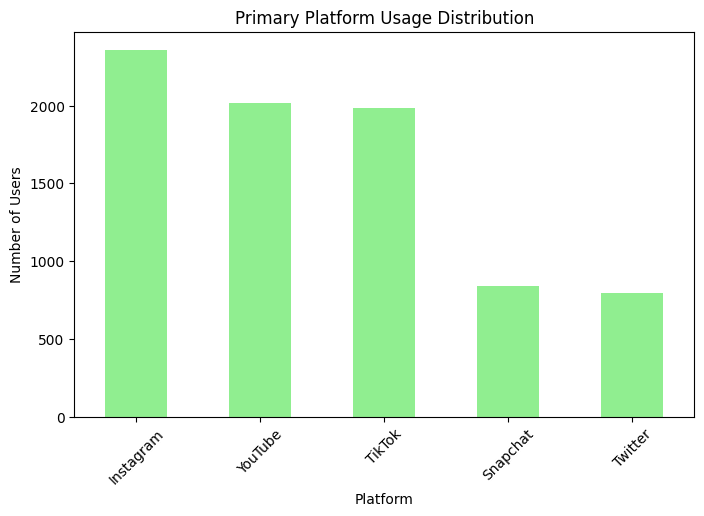

In [23]:
plt.figure(figsize=(8,5))
df['primary_platform'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Primary Platform Usage Distribution')
plt.xlabel('Platform')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.show()

**Insight:** Instagram is the most widely used primary platform, followed 
by YouTube and TikTok — together these three dominate Gen Z's screen time.

### 3.2 Average Daily Usage by Age Group
Does content consumption vary across different age groups within Gen Z?

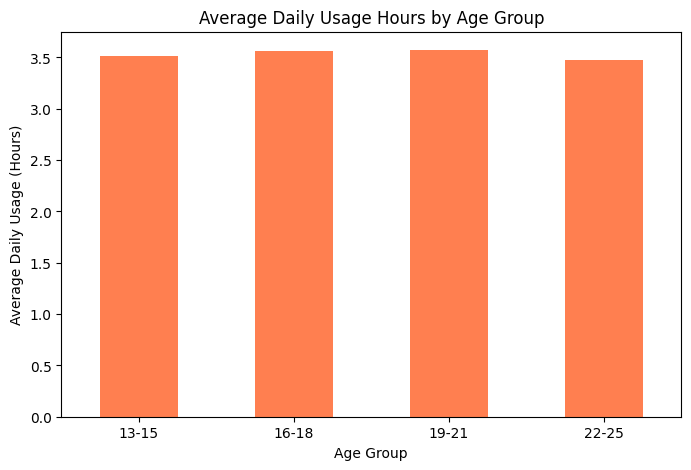

In [24]:
plt.figure(figsize=(8,5))
df.groupby('age_group',observed=False)['daily_usage_hours'].mean().plot(kind='bar', color='coral')
plt.title('Average Daily Usage Hours by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Daily Usage (Hours)')
plt.xticks(rotation=0)
plt.show()

**Insight:** The [16-18 and 19-21] age group shows the highest average daily usage, 
suggesting content consumption habits shift as users move through their teens.

### 3.3 Purpose of Content Consumption
What are users primarily using these platforms for — entertainment, 
education, socializing, or something else?

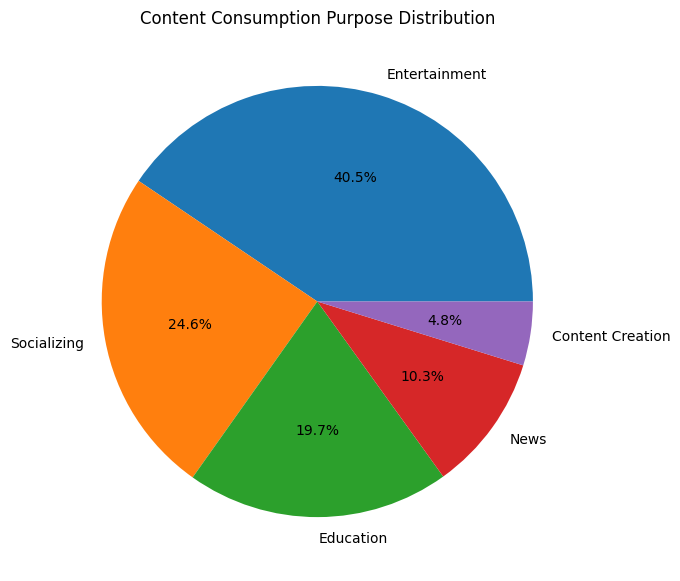

In [26]:
plt.figure(figsize=(7,7))
df['purpose'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Content Consumption Purpose Distribution')
plt.ylabel('')
plt.show()

**Insight:** Entertainment is the dominant purpose, accounting for a 
significant share of usage, followed by Socializing and Education.

### 3.4 Distribution of Daily Usage Hours
How is daily usage time distributed across all users — is it concentrated 
around a specific range, or widely spread?

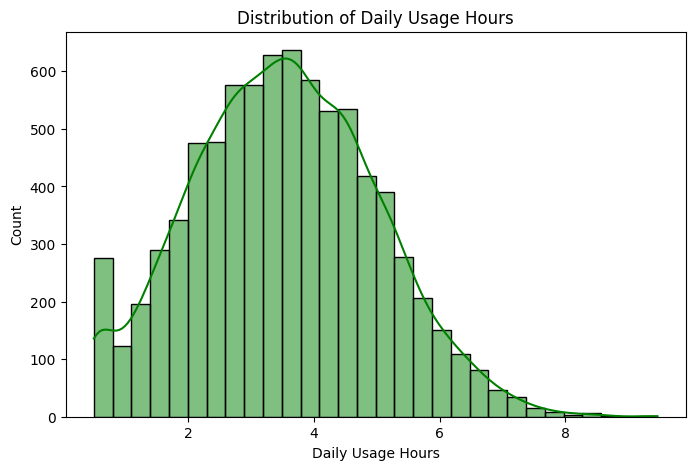

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['daily_usage_hours'], bins=30, kde=True, color='green')
plt.title('Distribution of Daily Usage Hours')
plt.xlabel('Daily Usage Hours')
plt.show()

**Insight:** Most users fall within a moderate usage range, with a smaller 
tail of users showing significantly higher daily usage hours.

### 3.5 Daily Usage Hours by Addiction Level
Is there a visible relationship between self-reported addiction level and 
actual daily usage hours?

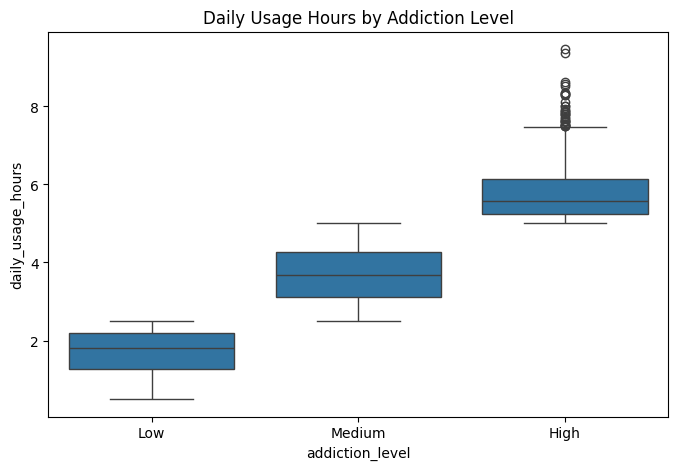

In [28]:
plt.figure(figsize=(8,5))
sns.boxplot(x='addiction_level', y='daily_usage_hours', data=df, order=['Low', 'Medium', 'High'])
plt.title('Daily Usage Hours by Addiction Level')
plt.show()

**Insight:** Users classified with a "High" addiction level show noticeably 
higher median daily usage compared to "Low" and "Medium" groups, suggesting 
usage hours and addiction level are related — though this is a pattern, 
not a clinical conclusion.

### 3.6 Correlation Between Usage, Sleep, and Mental Health Indicators
Exploring whether longer usage or later screen time before sleep shows any 
relationship with the mental health score in this dataset.

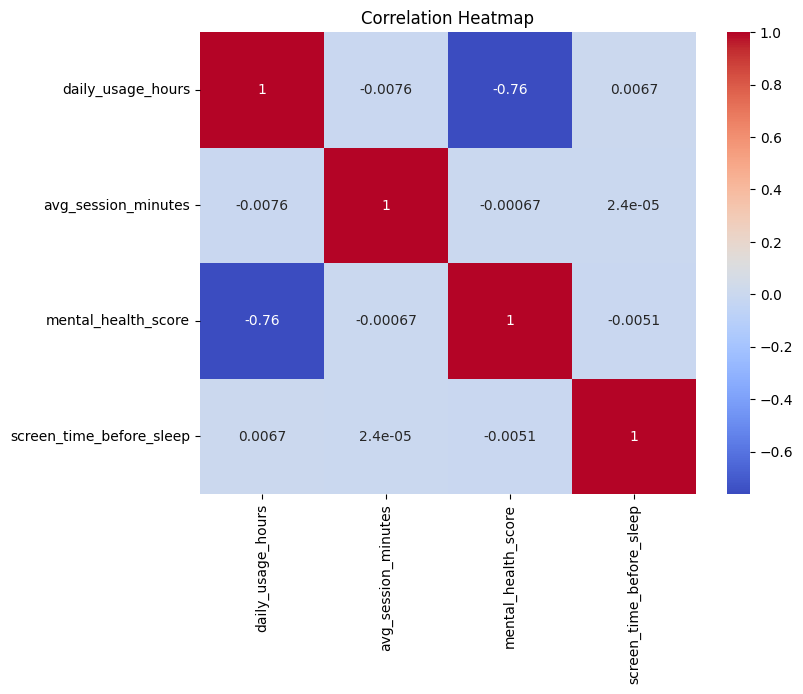

In [29]:
plt.figure(figsize=(8,6))
numeric_cols = ['daily_usage_hours', 'avg_session_minutes', 'mental_health_score', 'screen_time_before_sleep']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Insight:** [Describe what the heatmap shows — e.g., "Screen time before 
sleep shows a mild negative correlation with mental health score, while 
daily usage hours and session minutes are positively correlated with 
each other."]

In [30]:
df.to_csv('genz_cleaned_data.csv', index=False)
print("File saved successfully!")

File saved successfully!


## 4. Summary & Business Recommendations

**Key Findings:**
- Instagram, YouTube, and TikTok dominate Gen Z's platform usage
- Entertainment is the primary driver of content consumption
- Usage patterns vary meaningfully across age groups
- Higher usage hours correlate with higher self-reported addiction levels

**Recommendations (for a media/content company):**
- Prioritize short-form, entertainment-first content for platform strategy
- Target the [16-21] age group specifically, as they show highest engagement
- Consider promoting healthy usage awareness given the usage-addiction pattern

Cleaned dataset exported as `genz_cleaned_data.csv` for further analysis in SQL and Power BI.